In [1]:
import torch
from datasets import load_dataset
from transformers import AutoTokenizer
!pip install -q torch transformer_lens einops datasets huggingface_hub wandb tqdm numpy kaleido
import torch
from datasets import load_dataset
import os
from pathlib import Path
import argparse
import json
from IPython import get_ipython # Only needed for arg_parse_update_cfg if running interactively

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.2/195.2 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 74.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 739.7/739.7 kB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 4.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires google

# Code

In [2]:
import torch
from datasets import load_dataset
from transformers import AutoTokenizer

def load_pile_lmsys_mixed_tokens(cache_dir="/workspace/cache/", data_dir="/workspace/data/"):

    # =====================
    # Config
    # =====================
    MODEL_NAME = "Qwen/Qwen3-0.6B"
    DATASET_NAME = "AIPlans/Helpsteer2-helpfulness-prompts"
    TEXT_COLUMN = "prompt"
    
    SEQ_LEN =  256             # change if needed
    OUTPUT_PATH = "helpsteer2_qwen3_tokens.pt"
    BATCH_SIZE = 1000
    
    # =====================
    # Load tokenizer
    # =====================
    tokenizer = AutoTokenizer.from_pretrained(
        MODEL_NAME,
        use_fast=True,
        trust_remote_code=True
    )
    
    # Safety check
    assert tokenizer.pad_token_id is not None or True  # not used anyway
    
    # =====================
    # Load dataset
    # =====================
    dataset = load_dataset(DATASET_NAME, split="train")
    
    print("Dataset size:", len(dataset))
    
    # =====================
    # Tokenize to continuous stream
    # =====================
    all_token_ids = []
    
    for i in range(0, len(dataset), BATCH_SIZE):
        batch = dataset[i:i + BATCH_SIZE][TEXT_COLUMN]
    
        enc = tokenizer(
            batch,
            add_special_tokens=False,   # IMPORTANT
            return_attention_mask=False,
            return_token_type_ids=False,
            truncation=False
        )
    
        for ids in enc["input_ids"]:
            all_token_ids.extend(ids)
    
    print("Total tokens:", len(all_token_ids))
    
    # =====================
    # Convert to tensor & chunk
    # =====================
    tokens = torch.tensor(all_token_ids, dtype=torch.long)
    
    num_sequences = tokens.numel() // SEQ_LEN
    usable_tokens = num_sequences * SEQ_LEN
    
    tokens = tokens[:usable_tokens]
    tokens_2d = tokens.view(num_sequences, SEQ_LEN)
    
    print("Final tensor shape:", tokens_2d.shape)
    
    # =====================
    # Save
    # =====================
    torch.save(tokens_2d, OUTPUT_PATH)
    
    print(f"Saved to: {OUTPUT_PATH}")
    return tokens_2d

In [3]:
def arg_parse_update_cfg(default_cfg):
    return default_cfg

# Define available data types
DTYPES = {"fp32": torch.float32, "fp16": torch.float16, "bf16": torch.bfloat16}
import torch
import torch.nn as nn
import torch.nn.functional as F
import einops
import json
from pathlib import Path
from typing import NamedTuple, Optional, Union
from huggingface_hub import hf_hub_download
import pprint # For printing config nicely
# Define a structure for the loss output for clarity
class LossOutput(NamedTuple):
    l2_loss: torch.Tensor           # Reconstruction error
    l1_loss: torch.Tensor           # Sparsity penalty
    l0_loss: torch.Tensor           # Count of active features
    explained_variance: torch.Tensor # Overall variance explained
    explained_variance_A: torch.Tensor # Variance explained for Model A
    explained_variance_B: torch.Tensor # Variance explained for Model B


class CrossCoder(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        d_hidden = self.cfg["dict_size"]
        self.device = self.cfg["device"] # Store the device as an instance attribute
        d_in = self.cfg["d_in"]
        n_models = 2
        self.dtype = DTYPES[self.cfg["enc_dtype"]]
        torch.manual_seed(self.cfg["seed"])


        self.W_enc = nn.Parameter(torch.empty(n_models, d_in, d_hidden, dtype=self.dtype))
        self.b_enc = nn.Parameter(torch.zeros(d_hidden, dtype=self.dtype))
        self.W_dec = nn.Parameter(torch.empty(d_hidden, n_models, d_in, dtype=self.dtype))
        self.b_dec = nn.Parameter(torch.zeros((n_models, d_in), dtype=self.dtype))


        nn.init.normal_(self.W_dec, std=1.0)
        dec_norm = self.W_dec.norm(dim=-1, keepdim=True)
        self.W_dec.data /= (dec_norm + 1e-8)
        self.W_dec.data *= self.cfg["dec_init_norm"]
        self.W_enc.data = einops.rearrange(self.W_dec.data.clone(), "h n d -> n d h")


        self.d_hidden = d_hidden
        self.to(self.cfg["device"])
        self.save_dir = None
        self.save_version = 0
        print(f"CrossCoder (BatchTopK variant) initialized on device: {self.cfg['device']}")
        if self.cfg.get("sparsity_type", "l1") == "batch_top_k":
              assert "k_sparsity" in self.cfg, "k_sparsity must be in cfg for BatchTopK"
              print(f"Using BatchTopK sparsity with k={self.cfg['k_sparsity']}")




    def get_pre_activations(self, x: torch.Tensor) -> torch.Tensor:
        """Calculates pre-activations (before ReLU or TopK)."""
        x_enc = einops.einsum(x, self.W_enc, "b n d, n d h -> b h")
        pre_acts = x_enc + self.b_enc # Shape: [batch, d_hidden]
        return pre_acts


    def encode(self, x: torch.Tensor, is_training: bool = True) -> torch.Tensor:
        """
        Encodes input activations. Applies BatchTopK if training and configured.
        Otherwise, applies ReLU (for inference or L1 mode).
        """
        pre_acts = self.get_pre_activations(x) # Shape: [batch, d_hidden]


        if is_training and self.cfg.get("sparsity_type", "l1") == "batch_top_k":
            # BatchTopK logic (as described in the paper for f_train)
            # 1. Calculate scaling values v(xi, j) = fj(xi) * (||d_base_j||_2 + ||d_chat_j||_2)
            #    where fj(xi) is the ReLU of pre_acts.
            #    For simplicity, we'll use pre_acts directly for ranking initially,
            #    as the paper's v calculation is based on fj(xi) (post-ReLU)
            #    and decoder norms, which can be computationally intensive per step.
            #    A common simplification in SAEs is to use pre-ReLU for TopK.
            #    Let's refine this based on the paper's f_train definition:
            #    v(xi,j) = ReLU(pre_acts[i,j]) * (||W_dec[j,0,:]|| + ||W_dec[j,1,:]||)


            relu_acts = F.relu(pre_acts) # fj(xi)


            with torch.no_grad(): # Decoder norms don't need gradients here
                decoder_norms_sum = self.W_dec.norm(p=2, dim=-1).sum(dim=-1) # Shape [d_hidden]
                                                                        # (||d_base_j|| + ||d_chat_j||)


            v_values = relu_acts * decoder_norms_sum.unsqueeze(0) # Shape [batch, d_hidden]


            k = self.cfg["k_sparsity"]
            num_inputs = x.shape[0] # batch_size
            num_to_select_total = num_inputs * k # Total top activations across the batch


            # Flatten v_values to find global top-k across batch and features
            top_k_values, _ = torch.topk(v_values.flatten(), k=num_to_select_total)


            if top_k_values.numel() == 0: # Handle case where no values are selected (e.g. k=0)
                  # If k=0 or no positive activations, all are zero
                  threshold = float('inf')
            elif num_to_select_total == 0: # k=0
                  threshold = float('inf')
            else:
                  # The threshold is the k-th largest value
                  threshold = top_k_values[-1]




            # Create a mask for activations >= threshold
            # Only keep activations if their v_value was among the top k*N
            train_acts_mask = v_values >= threshold


            # Apply the mask to the ReLU activations (not pre_acts directly for f_train)
            # This ensures f_train (output here) matches the paper's f_j(x_i) for selected, 0 otherwise
            final_acts = relu_acts * train_acts_mask.float()


        else: # Standard ReLU for inference or if L1 sparsity is used
            final_acts = F.relu(pre_acts)


        return final_acts




    def decode(self, acts: torch.Tensor) -> torch.Tensor:
        # (decode function remains the same)
        acts_dec = einops.einsum(acts, self.W_dec, "b h, h n d -> b n d")
        x_reconstruct = acts_dec + self.b_dec
        return x_reconstruct


    def forward(self, x: torch.Tensor, is_training: bool = True) -> torch.Tensor:
        # Pass is_training to encode
        acts = self.encode(x, is_training=is_training)
        x_reconstruct = self.decode(acts)
        return x_reconstruct


    def get_losses(self, x: torch.Tensor, is_training: bool = True) -> LossOutput:
        x = x.to(self.cfg["device"]).to(self.dtype)


        # --- Forward pass (use is_training for encode) ---
        acts = self.encode(x, is_training=is_training)
        x_reconstruct = self.decode(acts)


        # --- L2 Loss (Mean Squared Error) ---
        diff = (x_reconstruct - x).float()
        squared_diff = diff.pow(2)
        l2_per_batch = einops.reduce(squared_diff, 'b n d -> b', 'sum')
        l2_loss = l2_per_batch.mean()


        # --- Sparsity Related Losses ---
        l1_loss_val = torch.tensor(0.0, device=self.device) # Default for BatchTopK
        l0_loss_val = (acts > 1e-8).float().sum(dim=-1).mean() # L0 is always informative


        if self.cfg.get("sparsity_type", "l1") == "l1":
            # Calculate L1 loss if configured (original method)
            with torch.no_grad():
                  decoder_norms = self.W_dec.norm(dim=-1)
                  total_decoder_norm = einops.reduce(decoder_norms, 'h n -> h', 'sum')
            l1_loss_val = (acts.float() * total_decoder_norm[None, :]).sum(dim=-1).mean()
        elif self.cfg.get("sparsity_type", "l1") == "batch_top_k":
            # For BatchTopK, the primary loss is L2.
            # The paper mentions an auxiliary loss (L_aux) for recycling dead latents.
            # We'll add a placeholder; a simple L_aux could be an L1 on pre-activations
            # or encouraging dead neurons to fire. This requires more careful implementation
            # from the Bussmann et al. paper or a similar strategy.
            # For now, we only have the L2 and the L0 is just for monitoring.
            # The sparsity is *enforced* by the TopK selection in encode().
            pass # No direct L1 term. Sparsity is structural.


        # --- Explained Variance ---
        with torch.no_grad():
            variance = einops.reduce((x - x.mean(dim=0, keepdim=True)).pow(2), 'b n d -> b', 'sum')
            explained_variance = (1 - l2_per_batch / (variance + 1e-8)).mean()
            variance_A = (x[:, 0] - x[:, 0].mean(dim=0, keepdim=True)).pow(2).sum(dim=-1)
            l2_per_batch_A = squared_diff[:, 0].sum(dim=-1)
            explained_variance_A = (1 - l2_per_batch_A / (variance_A + 1e-8)).mean()
            variance_B = (x[:, 1] - x[:, 1].mean(dim=0, keepdim=True)).pow(2).sum(dim=-1)
            l2_per_batch_B = squared_diff[:, 1].sum(dim=-1)
            explained_variance_B = (1 - l2_per_batch_B / (variance_B + 1e-8)).mean()


        return LossOutput(l2_loss, l1_loss_val, l0_loss_val, explained_variance, explained_variance_A, explained_variance_B)


    def create_save_dir(self, base_dir_str="./checkpoints"):
        base_dir = Path(base_dir_str)
        base_dir.mkdir(parents=True, exist_ok=True) # Ensure base directory exists




        # Find existing version directories
        version_list = []
        for file in base_dir.iterdir():
            if file.is_dir() and file.name.startswith("version_"):
                try:
                    version_list.append(int(file.name.split("_")[1]))
                except (IndexError, ValueError):
                    continue # Ignore directories not matching the pattern




        # Determine the next version number
        if version_list:
            version = 1 + max(version_list)
        else:
            version = 0




        self.save_dir = base_dir / f"version_{version}"
        self.save_dir.mkdir(parents=True)
        print(f"Created checkpoint directory: {self.save_dir}")


    def save(self, checkpoint_dir_str="./checkpoints"):
        """Saves the model state dictionary and config."""
        if self.save_dir is None:
            self.create_save_dir(checkpoint_dir_str)




        # Define file paths within the versioned directory
        weight_path = self.save_dir / f"crosscoder_{self.save_version}.pt"
        cfg_path = self.save_dir / f"crosscoder_{self.save_version}_cfg.json"




        # Save the model's learned parameters
        torch.save(self.state_dict(), weight_path)




        # Save the configuration used for this model
        with open(cfg_path, "w") as f:
            # Convert Path objects in config to strings for JSON serialization
            serializable_cfg = {k: str(v) if isinstance(v, Path) else v for k, v in self.cfg.items()}
            json.dump(serializable_cfg, f, indent=2)




        print(f"Saved checkpoint {self.save_version} to {self.save_dir}")
        self.save_version += 1 # Increment version for the next save


    @classmethod
    def load(cls, version_dir_str: str, checkpoint_version: int = 0):
          """Loads a CrossCoder model from a saved checkpoint directory."""
          save_dir = Path(version_dir_str)
          cfg_path = save_dir / f"crosscoder_{checkpoint_version}_cfg.json"
          weight_path = save_dir / f"crosscoder_{checkpoint_version}.pt"




          if not cfg_path.exists() or not weight_path.exists():
                raise FileNotFoundError(f"Checkpoint files not found in {save_dir} for version {checkpoint_version}")


          print(f"Loading config from: {cfg_path}")
          with open(cfg_path, "r") as f:
              cfg = json.load(f)
          print("Loaded Config:")
          pprint.pprint(cfg)




          # Create a new instance with the loaded config
          # Ensure device is handled correctly if loading on different hardware
          if 'device' not in cfg:
                cfg['device'] = 'cuda:0' if torch.cuda.is_available() else 'cpu'
                print(f"Warning: 'device' not found in config, defaulting to {cfg['device']}")
          instance = cls(cfg=cfg)




          print(f"Loading weights from: {weight_path}")
          # Load the saved weights onto the correct device specified in the config
          state_dict = torch.load(weight_path, map_location=cfg["device"])
          instance.load_state_dict(state_dict)
          print("Weights loaded successfully.")




          instance.save_dir = save_dir # Set save_dir for potential future saves
          instance.save_version = checkpoint_version + 1 # Start saving from next version
          return instance


    @classmethod
    def load_from_hf(
            cls,
            repo_id: str = "ckkissane/crosscoder-gemma-2-2b-model-diff",
            path_in_repo: str = "blocks.14.hook_resid_pre", # Original path structure
            cfg_filename: str = "cfg.json",
            weights_filename: str = "cc_weights.pt",
            device: Optional[Union[str, torch.device]] = None,
            **kwargs # Pass extra args to hf_hub_download (e.g., token)
        ):
            print(f"Loading CrossCoder from HF Hub: {repo_id}/{path_in_repo}")


            # Construct full paths within the repo
            config_repo_path = f"{path_in_repo}/{cfg_filename}"
            weights_repo_path = f"{path_in_repo}/{weights_filename}"




            # Download config and weights files
            try:
                config_path = hf_hub_download(
                    repo_id=repo_id,
                    filename=config_repo_path,
                    **kwargs
                )
                weights_path = hf_hub_download(
                    repo_id=repo_id,
                    filename=weights_repo_path,
                    **kwargs
                )
            except Exception as e:
                print(f"Error downloading from Hugging Face Hub: {e}")
                raise
            print(f"Downloaded config: {config_path}")
            print(f"Downloaded weights: {weights_path}")


            # Load config from the downloaded JSON file
            with open(config_path, 'r') as f:
                cfg = json.load(f)
            print("Loaded Config:")
            pprint.pprint(cfg)


            # Determine the device
            if device is None:
                # Use device from config if available, otherwise default
                if 'device' in cfg:
                    device = cfg['device']
                else:
                    device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
                    print(f"Warning: 'device' not found in config, defaulting to {device}")
            # Update config with the determined device (important for model initialization)
            cfg["device"] = str(device)
            # Initialize CrossCoder instance with the loaded config
            instance = cls(cfg)


            # Load weights onto the specified device
            state_dict = torch.load(weights_path, map_location=device)
            instance.load_state_dict(state_dict)
            print(f"Weights loaded successfully onto device: {device}")
            return instance

In [5]:
# Cell 3: Define the Activation Buffer (Conceptually buffer.py)

import torch
import einops
import tqdm # For progress bars
import numpy as np
from transformer_lens import HookedTransformer, ActivationCache # Needs transformer_lens installed

# Assuming the CrossCoder class from the previous cell is already defined/executed

class Buffer:
    """
    Manages a buffer of activation pairs from two models (A and B).
    Runs the models on token data to generate activations, normalizes them,
    stores them, shuffles, and provides batches for training the CrossCoder.
    Refreshes the buffer periodically with new data.
    """
    def __init__(self, cfg: dict, model_A: HookedTransformer, model_B: HookedTransformer, all_tokens: torch.Tensor):
        """
        Initializes the Buffer.

        Args:
            cfg (dict): Configuration dictionary. Expects keys like:
                        'batch_size', 'buffer_mult', 'seq_len', 'device',
                        'model_batch_size', 'hook_point', 'd_in'.
            model_A (HookedTransformer): The first language model instance.
            model_B (HookedTransformer): The second language model instance.
            all_tokens (torch.Tensor): A large tensor of tokenized text data.
        """
        self.cfg = cfg
        self.device = cfg["device"]
        self.model_A = model_A
        self.model_B = model_B
        self.all_tokens = all_tokens.to(self.device) # Move tokens to the target device

        # Ensure models have the same hidden dimension
        assert model_A.cfg.d_model == model_B.cfg.d_model
        assert model_A.cfg.d_model == cfg["d_in"] # Match config d_in

        # --- Buffer Size Calculation ---
        # Size of buffer in terms of activation vectors
        self.buffer_size_target = cfg["batch_size"] * cfg["buffer_mult"]
        # Number of sequences needed to approximately fill the buffer
        # -1 because we drop the BOS token activation
        self.buffer_batches = self.buffer_size_target // (cfg["seq_len"] - 1)
        # Actual buffer size based on full sequences
        self.buffer_size = self.buffer_batches * (cfg["seq_len"] - 1)
        print(f"Buffer target size: {self.buffer_size_target}, actual size: {self.buffer_size}")

        # --- Initialize Buffer Tensor ---
        # Shape: [buffer_size, n_models=2, d_model]
        self.buffer = torch.zeros(
            (self.buffer_size, 2, cfg["d_in"]),
            dtype=torch.bfloat16, # Use bfloat16 for memory efficiency during storage
            device=self.device,
            requires_grad=False, # No gradients needed for buffer data
        )
        print(f"Initialized buffer tensor with shape: {self.buffer.shape} on device: {self.device}")

        # --- Pointers and Flags ---
        self.token_pointer = 0 # Tracks position in the all_tokens dataset
        self.pointer = 0       # Tracks position within the local buffer
        self.first = True      # Flag for initial full buffer refresh
        self.normalize = True  # Flag to control normalization (should usually be True)

        # --- Activation Normalization ---
        # Estimate scaling factors to make avg norm sqrt(d_model) for each model's activations
        print("Estimating activation norm scaling factors...")
        # Use a smaller batch size for norm estimation if model_batch_size is large
        norm_batch_size = min(cfg.get("norm_batch_size", 16), cfg["model_batch_size"])
        estimated_norm_scaling_factor_A = self.estimate_norm_scaling_factor(norm_batch_size, model_A)
        estimated_norm_scaling_factor_B = self.estimate_norm_scaling_factor(norm_batch_size, model_B)

        # Store factors as a tensor on the correct device
        self.normalisation_factor = torch.tensor(
            [estimated_norm_scaling_factor_A, estimated_norm_scaling_factor_B],
            device=self.device,
            dtype=torch.float32, # Use float32 for the scaling factor itself
        ).unsqueeze(0).unsqueeze(-1) # Reshape to [1, 2, 1] for broadcasting
        print(f"Normalization factors (A, B): {self.normalisation_factor.squeeze().tolist()}")

        # --- Initial Data Refresh ---
        print("Performing initial buffer refresh...")
        self.refresh()
        print("Initial buffer refresh complete.")


    @torch.no_grad() # Disable gradient calculations for this method
    def estimate_norm_scaling_factor(self, batch_size: int, model: HookedTransformer, n_batches_for_norm_estimate: int = 100) -> float:
        """
        Estimates the factor needed to scale activations at the hook point
        so their average norm is sqrt(d_model).

        Args:
            batch_size (int): Batch size for running the model during estimation.
            model (HookedTransformer): The model instance.
            n_batches_for_norm_estimate (int): Number of batches to average over.

        Returns:
            float: The calculated scaling factor.
        """
        # Adapted from SAELens library
        norms_per_batch = []
        total_estimation_tokens = batch_size * n_batches_for_norm_estimate
        if total_estimation_tokens > self.all_tokens.shape[0] * self.all_tokens.shape[1]:
             print(f"Warning: Not enough tokens ({self.all_tokens.shape[0]*self.all_tokens.shape[1]}) for full norm estimation ({total_estimation_tokens}). Using fewer batches.")
             n_batches_for_norm_estimate = (self.all_tokens.shape[0] * self.all_tokens.shape[1]) // batch_size
             if n_batches_for_norm_estimate == 0:
                 print("Error: Very few tokens, cannot estimate norm factor.")
                 return 1.0 # Default to 1 if too few tokens

        print(f"Estimating norm factor using {n_batches_for_norm_estimate} batches of size {batch_size}...")

        # Use a temporary pointer for token fetching during estimation
        estimation_token_pointer = 0
        for i in tqdm.trange(n_batches_for_norm_estimate, desc=f"Estimating norm for {model.cfg.model_name}"):
            # Get a batch of tokens
            end_idx = estimation_token_pointer + batch_size
            if end_idx > self.all_tokens.shape[0]: # Handle wrapping around token dataset
                 print("Warning: Wrapping token dataset during norm estimation.")
                 tokens = torch.cat([self.all_tokens[estimation_token_pointer:], self.all_tokens[:end_idx % self.all_tokens.shape[0]]], dim=0)
                 estimation_token_pointer = end_idx % self.all_tokens.shape[0]
            else:
                 tokens = self.all_tokens[estimation_token_pointer:end_idx]
                 estimation_token_pointer = end_idx

            # Ensure tokens are on the correct device
            tokens = tokens.to(self.device)

            # Run model and get activations at the hook point
            # Use inference_mode for efficiency as we don't need gradients here
            with torch.inference_mode():
                _, cache = model.run_with_cache(
                    tokens,
                    names_filter=self.cfg["hook_point"],
                    return_type=None, # Don't need final model output
                )
            # Extract activations [batch, seq_len, d_model]
            acts = cache[self.cfg["hook_point"]]
            # Drop BOS token activation [batch, seq_len-1, d_model]
            acts_no_bos = acts[:, 1:, :]
            # Calculate norm along the d_model dimension, then average over seq and batch
            # Use float32 for norm calculation stability
            avg_norm = acts_no_bos.norm(dim=-1, p=2).float().mean().item()
            norms_per_batch.append(avg_norm)

        # Calculate the overall mean norm
        mean_norm = np.mean(norms_per_batch)
        # Calculate scaling factor to reach target norm = sqrt(d_model)
        target_norm = np.sqrt(self.cfg["d_in"])
        scaling_factor = target_norm / (mean_norm + 1e-8) # Add epsilon for stability
        print(f"  Avg activation norm: {mean_norm:.4f}, Target norm: {target_norm:.4f}, Scaling factor: {scaling_factor:.4f}")

        return scaling_factor

    @torch.no_grad() # Disable gradient calculations for this method
    def refresh(self):
        """
        Refreshes the buffer by generating new activation pairs from the models.
        Fills either the whole buffer (first time) or the second half.
        Shuffles the buffer afterwards.
        """
        # Determine the start and end pointers for filling the buffer
        start_idx = self.buffer_size // 2 if not self.first else 0
        end_idx = self.buffer_size
        num_activations_to_generate = end_idx - start_idx

        # Calculate how many sequences we need to process
        num_sequences_needed = num_activations_to_generate // (self.cfg["seq_len"] - 1)

        print(f"Refreshing buffer: Filling indices [{start_idx}:{end_idx}] ({num_activations_to_generate} activations)")
        print(f"Need to process {num_sequences_needed} sequences.")

        # Pointer within the buffer where we'll write next
        write_pointer = start_idx

        # Use model_batch_size for generation efficiency
        model_batch_size = self.cfg["model_batch_size"]

        # Loop through batches of sequences from the token dataset
        # Use tqdm for a progress bar over sequences
        for i in tqdm.trange(0, num_sequences_needed, model_batch_size, desc="Refreshing Buffer"):
            # Get batch of token sequences
            batch_start = self.token_pointer
            batch_end = batch_start + model_batch_size

            # Handle wrapping around the token dataset if we reach the end
            if batch_end > self.all_tokens.shape[0]:
                print("Wrapping token dataset during buffer refresh.")
                tokens1 = self.all_tokens[batch_start:]
                remaining = model_batch_size - tokens1.shape[0]
                tokens2 = self.all_tokens[:remaining]
                tokens = torch.cat([tokens1, tokens2], dim=0)
                self.token_pointer = remaining # Update pointer for next iteration
            else:
                tokens = self.all_tokens[batch_start:batch_end]
                self.token_pointer = batch_end

            # Ensure tokens are on the correct device
            tokens = tokens.to(self.device)

            # Run models and get caches (use inference mode for speed)
            with torch.inference_mode(), torch.autocast("cuda" if "cuda" in str(self.device) else "cpu", dtype=torch.bfloat16): # Autocast for potential speedup/memory saving
                _, cache_A = self.model_A.run_with_cache(
                    tokens, names_filter=self.cfg["hook_point"], return_type=None
                )
                _, cache_B = self.model_B.run_with_cache(
                    tokens, names_filter=self.cfg["hook_point"], return_type=None
                )

            # Extract activations [batch, seq_len, d_model]
            acts_A = cache_A[self.cfg["hook_point"]]
            acts_B = cache_B[self.cfg["hook_point"]]

            # Stack activations [2, batch, seq_len, d_model]
            acts_stacked = torch.stack([acts_A, acts_B], dim=0)

            # Drop BOS token: [2, batch, seq_len-1, d_model]
            acts_no_bos = acts_stacked[:, :, 1:, :]

            # Reshape for buffer: [(batch * (seq_len-1)), 2, d_model]
            acts_reshaped = einops.rearrange(
                acts_no_bos,
                "n_models batch seq_len_minus_1 d_model -> (batch seq_len_minus_1) n_models d_model",
            )

            # Determine how many activations we generated in this batch
            num_generated = acts_reshaped.shape[0]
            write_end = write_pointer + num_generated

            # Write the generated activations into the buffer
            # Ensure we don't write past the intended end_idx if model_batch_size doesn't divide perfectly
            if write_end > end_idx:
                 num_to_write = end_idx - write_pointer
                 self.buffer[write_pointer:end_idx] = acts_reshaped[:num_to_write].to(self.buffer.dtype) # Cast back to buffer dtype (bfloat16)
                 write_pointer = end_idx # We are done
            else:
                 self.buffer[write_pointer:write_end] = acts_reshaped.to(self.buffer.dtype)
                 write_pointer = write_end

            # Break if we've filled the required portion
            if write_pointer >= end_idx:
                break

        # --- Shuffle the entire buffer ---
        print("Shuffling buffer...")
        # Generate random permutation of indices
        permutation = torch.randperm(self.buffer_size, device=self.device)
        # Apply permutation
        self.buffer = self.buffer[permutation]
        print("Buffer shuffled.")

        # Reset the buffer pointer to the beginning
        self.pointer = 0
        # Set first flag to False after the initial fill
        self.first = False


    @torch.no_grad() # Disable gradient calculations for this method
    def next(self) -> torch.Tensor:
        """
        Returns the next batch of activation pairs from the buffer.
        Refreshes the second half of the buffer if the pointer passes the halfway mark.

        Returns:
            torch.Tensor: A batch of normalized activation pairs,
                          shape [batch_size, 2, d_model], dtype float32.
        """
        batch_size = self.cfg["batch_size"]
        out = self.buffer[self.pointer : self.pointer + batch_size]

        # Move pointer for the next batch
        self.pointer += batch_size

        # Check if we need to refresh (pointer crossed halfway point)
        # Refresh slightly before strictly necessary to avoid waiting
        if self.pointer >= self.buffer_size // 2:
            print(f"\nBuffer pointer at {self.pointer}, refreshing...")
            self.refresh() # This refills the second half and reshuffles

        # --- Normalize and Cast ---
        # Apply pre-calculated normalization factors
        # Normalisation factor shape [1, 2, 1], out shape [batch, 2, d_model]
        if self.normalize:
            out_normalized = out.float() * self.normalisation_factor # Cast to float32 for multiplication
        else:
            out_normalized = out.float() # Still cast to float32 for training consistency

        return out_normalized

In [6]:
import torch
import torch.optim as optim
from torch.nn.utils import clip_grad_norm_
import wandb # Make sure wandb is installed and you're logged in via terminal (`wandb login`)
import tqdm
import math # For checking NaN/inf
class Trainer:
    def __init__(self, cfg: dict, crosscoder: CrossCoder, buffer: Buffer):
        """
        Initializes the Trainer.


        Args:
            cfg (dict): Configuration dictionary. Expects keys like:
                        'batch_size', 'num_tokens', 'lr', 'beta1', 'beta2',
                        'l1_coeff', 'wandb_project',, 'log_every',
                        'save_every', 'device'.
            crosscoder (CrossCoder): The CrossCoder model instance to train.
            buffer (Buffer): The initialized Buffer instance providing activation data.
        """
        self.cfg = cfg
        self.crosscoder = crosscoder
        self.buffer = buffer
        self.device = cfg["device"]


        # Calculate total training steps based on tokens and batch size
        self.total_steps = cfg["num_tokens"] // cfg["batch_size"]
        print(f"Total training steps calculated: {self.total_steps}")




        # --- Optimizer ---
        # Adam optimizer is commonly used for training neural networks
        self.optimizer = optim.Adam(
            self.crosscoder.parameters(), # Pass the model's learnable parameters
            lr=cfg["lr"],                 # Learning rate
            betas=(cfg["beta1"], cfg["beta2"]), # Adam specific hyperparameters
            # weight_decay=cfg.get("weight_decay", 0.0) # Optional: L2 regularization on weights
        )
        print(f"Initialized Adam optimizer with LR: {cfg['lr']}")




        # --- Learning Rate Scheduler ---
        # Defines how the learning rate changes during training.
        # Here: constant LR for 80% of steps, then linear decay to 0.
        self.scheduler = optim.lr_scheduler.LambdaLR(
            self.optimizer, self.lr_lambda # lr_lambda is a method defined below
        )
        print("Initialized LR scheduler (constant then linear decay).")


        # --- Step Counter ---
        self.step_counter = 0


        # --- WandB Initialization ---
        # Connect to Weights & Biases for logging
        try:
            wandb.init(
                project=cfg["wandb_project"],
                config=cfg, # Log the configuration used for this run
                name=cfg.get("wandb_run_name", None) # Optional: custom run name
            )
            print(f"WandB initialized for project '{cfg['wandb_project']}' ")
            # Watch the model gradients and parameters (optional, can be verbose)
            # wandb.watch(self.crosscoder, log_freq=max(100, cfg['log_every']), log='all')
        except Exception as e:
            print(f"Error initializing WandB: {e}")
            print("WandB logging will be disabled.")
            # Optionally disable wandb if init fails
            # wandb.init(mode="disabled")




    def lr_lambda(self, step: int) -> float:
        warmup_steps = self.cfg.get("lr_warmup_steps", 0) # Optional warmup
        decay_start_step = int(self.cfg.get("lr_decay_start_fraction", 0.8) * self.total_steps)
        if step < warmup_steps:
            return float(step) / float(max(1, warmup_steps))
        elif step < decay_start_step:
            return 1.0
        else:
            steps_into_decay = step - decay_start_step
            total_decay_steps = self.total_steps - decay_start_step
            decay_factor = 1.0 - (steps_into_decay / total_decay_steps)
            return max(0.0, decay_factor)
            
    def get_l1_coeff(self) -> float:
        l1_warmup_frac = self.cfg.get("l1_warmup_fraction", 0.05) # Fraction of total steps for ramp-up
        l1_warmup_steps = int(l1_warmup_frac * self.total_steps)
        target_l1_coeff = self.cfg["l1_coeff"]
        if self.step_counter < l1_warmup_steps:
            # Linear ramp-up from 0 to target_l1_coeff
            return target_l1_coeff * (self.step_counter / max(1, l1_warmup_steps))
        else:
            # Constant phase at the target coefficient
            return target_l1_coeff


    def step(self) -> dict:
        """
        Performs a single training step:
        1. Get data batch from buffer.
        2. Run forward pass and calculate losses.
        3. Run backward pass to get gradients.
        4. Clip gradients.
        5. Update model weights using optimizer.
        6. Update learning rate using scheduler.
        7. Zero gradients.
        8. Return loss dictionary for logging.




        Returns:
            dict: Dictionary containing loss values and other metrics for this step.
        """
        # Set model to training mode (important for dropout, batchnorm layers, though not used here)
        self.crosscoder.train() # Set model to training mode
        acts_input = self.buffer.next()


        # Pass is_training=True to get_losses, which will pass it to encode
        losses: LossOutput = self.crosscoder.get_losses(acts_input, is_training=True)


        # For BatchTopK, the loss is primarily L2. L1_coeff is not used for the main loss.
        if self.cfg.get("sparsity_type", "l1") == "batch_top_k":
            loss = losses.l2_loss
            # TODO: Add L_aux if implementing the full Bussmann et al. auxiliary loss
            # For now, L_aux is effectively 0
            current_l1_coeff = 0.0 # L1 coeff is not part of BatchTopK primary loss
        else: # Original L1 sparsity
            current_l1_coeff = self.get_l1_coeff()
            loss = losses.l2_loss + current_l1_coeff * losses.l1_loss




        # Check for NaN/inf loss, which indicates instability
        if not torch.isfinite(loss):
              print(f"\nWarning: Non-finite loss detected at step {self.step_counter}: {loss.item()}")
              print(f"  L2: {losses.l2_loss.item()}, L1: {losses.l1_loss.item()}, L1 Coeff: {current_l1_coeff}")
              # Optional: Add more debugging here, e.g., check gradients later
              # For now, just return the problematic losses without backprop
              loss_dict = {
                  "loss": loss.item(), # Log the NaN/inf
                  "l2_loss": losses.l2_loss.item(),
                  "l1_loss": losses.l1_loss.item(),
                  "l0_loss": losses.l0_loss.item(),
                  "l1_coeff": current_l1_coeff,
                  "lr": self.scheduler.get_last_lr()[0],
                  "explained_variance": losses.explained_variance.item(),
                  "explained_variance_A": losses.explained_variance_A.item(),
                  "explained_variance_B": losses.explained_variance_B.item(),
              }
              self.step_counter += 1 # Still increment step counter
              return loss_dict # Skip backprop and optimizer step








        # 3. Backward pass (calculate gradients)
        # Gradients are calculated for the combined loss
        loss.backward()




        # 4. Clip gradients (prevent exploding gradients)
        # max_norm=1.0 is a common value
        grad_norm = clip_grad_norm_(self.crosscoder.parameters(), max_norm=1.0)




        # 5. Optimizer step (update weights)
        self.optimizer.step()




        # 6. Scheduler step (update learning rate)
        self.scheduler.step()




        # 7. Zero gradients (clear gradients for the next iteration)
        self.optimizer.zero_grad()




        # 8. Prepare loss dictionary for logging
        loss_dict = {
            "loss": loss.item(),
            "l2_loss": losses.l2_loss.item(),
            "l1_loss": losses.l1_loss.item(),
            "l0_loss": losses.l0_loss.item(),
            "l1_coeff": current_l1_coeff,
            "lr": self.scheduler.get_last_lr()[0],
            "explained_variance": losses.explained_variance.item(),
            "explained_variance_A": losses.explained_variance_A.item(),
            "explained_variance_B": losses.explained_variance_B.item(),
            "grad_norm": grad_norm.item() # Log gradient norm after clipping
        }




        self.step_counter += 1
        return loss_dict




    def log(self, loss_dict: dict):
        """Logs the metrics dictionary to WandB and prints it."""
        # Log to WandB if initialized
        if wandb.run is not None:
            wandb.log(loss_dict, step=self.step_counter)




        # Print metrics locally (optional, can be verbose)
        log_str = f"Step: {self.step_counter:>7} | "
        log_str += f"Loss: {loss_dict['loss']:.4f} | "
        log_str += f"L2: {loss_dict['l2_loss']:.4f} | "
        log_str += f"L1: {loss_dict['l1_loss']:.4f} | "
        log_str += f"L0: {loss_dict['l0_loss']:.2f} | "
        log_str += f"ExplVar: {loss_dict['explained_variance']:.3f} | "
        log_str += f"LR: {loss_dict['lr']:.2e} | "
        log_str += f"L1Coeff: {loss_dict['l1_coeff']:.2f}"
        # Avoid printing every single step if logging frequently
        if self.step_counter % (self.cfg['log_every'] * 10) == 0 or self.step_counter <= 10:
              print(log_str)




    def save(self):
        """Saves a checkpoint of the CrossCoder model."""
        print(f"\nSaving checkpoint at step {self.step_counter}...")
        self.crosscoder.save(checkpoint_dir_str=self.cfg.get("checkpoint_path", "./checkpoints"))


    def train(self):
        """Runs the main training loop."""
        print("\n--- Starting Training ---")
        self.step_counter = 0 # Reset step counter at the beginning of training




        try:
            # Use tqdm for a progress bar over the total steps
            for i in tqdm.trange(self.total_steps, desc="Training Progress"):
                # Perform one training step
                loss_dict = self.step()




                # Log metrics periodically
                if i % self.cfg["log_every"] == 0:
                    self.log(loss_dict)




                # Save checkpoint periodically
                # Save at i+1 so the checkpoint name reflects the step *completed*
                if (i + 1) % self.cfg["save_every"] == 0:
                    self.save()




                # Optional: Add early stopping logic here if desired




        except KeyboardInterrupt:
            print("\nTraining interrupted by user.")
        except Exception as e:
              print(f"\nAn error occurred during training: {e}")
              import traceback
              traceback.print_exc() # Print detailed traceback
        finally:
            # --- Final Save ---
            # Always save the final model state, regardless of how training ended
            print("\n--- Training Finished or Interrupted ---")
            self.save()
            if wandb.run is not None:
                wandb.finish() # Ensure WandB run is marked as finished
                print("WandB run finished.")

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

# Running

In [7]:
import wandb
wandb.login(key="")
from huggingface_hub import login

login(token="")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: jithesh (jithesh-independent) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [8]:
from transformer_lens import HookedTransformer

model = HookedTransformer.from_pretrained("Qwen/Qwen3-0.6B")

target_hook = "blocks.14.hook_resid_pre"

# Check if hook exists
print(target_hook in model.hook_dict)

# Get its position among hooks
hook_names = list(model.hook_dict.keys())
print(hook_names.index(target_hook))

config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

Loaded pretrained model Qwen/Qwen3-0.6B into HookedTransformer
True
448


In [9]:
model.cfg.n_layers

28

In [10]:
# --- 1. Configuration ---
# Adjust paths and WandB details as needed!
cfg = {
    # --- Setup ---
    "seed": 49,
    "device": "cuda:0" if torch.cuda.is_available() else "cpu",
    "wandb_project": "CrossCoder_Model_Diffing", # <<< CHANGE THIS
    "wandb_entity": "jithesh",  # <<< CHANGE THIS
    "wandb_run_name": None,                 # Optional: Set a custom name for the run in WandB
    "checkpoint_path": "./checkpoints/",    # Directory to save model checkpoints
    "data_cache_dir": "./cache/",           # HF datasets cache directory
    "data_dir": "./data/",                  # Directory for processed token file


    # --- Model Config ---
    "hook_point": "blocks.14.hook_resid_pre", # Layer to extract activations
    # "d_in" will be set automatically from the loaded model


    # --- CrossCoder/SAE Config ---
    "dict_size": 2**14,             # Latent dimension (e.g., 16384)
    "enc_dtype": "fp32",            # Data type for CrossCoder weights
    "dec_init_norm": 0.08,          # Initial norm for decoder weights


    # --- Sparsity Configuration (CHOOSE ONE METHOD) ---


    # Method 1: BatchTopK Sparsity (Currently Active)
    "sparsity_type": "batch_top_k",
    "k_sparsity": 100,              # Avg. active latents per input in batch (e.g., 100)
    "l1_coeff": 0.0,                # L1 coeff MUST be 0.0 for pure BatchTopK
    "l1_warmup_fraction": 0.0,      # Not used if l1_coeff is 0.0


    # Method 2: L1 Sparsity (Currently Commented Out)
    # To use L1 sparsity, comment out the BatchTopK lines above and uncomment these:
    # "sparsity_type": "l1",            # Or simply remove this line to default to "l1"
    # "l1_coeff": 2.0,                  # Strength of L1 sparsity penalty
    # "l1_warmup_fraction": 0.05,       # Ramp up L1 coeff over first 5% of steps
    # "k_sparsity": 0,                  # Not used by L1 sparsity, can be 0 or removed


    # --- Training Hyperparameters ---
    "lr": 5e-5,                     # Learning rate
    "beta1": 0.9,                   # Adam optimizer beta1
    "beta2": 0.999,                 # Adam optimizer beta2
    "lr_warmup_steps": 0,           # Optional LR warmup
    "lr_decay_start_fraction": 0.8, # When to start LR decay


    # --- Data & Batching (ADJUST BASED ON YOUR GPU MEMORY!) ---
    "num_tokens": 10_000_000,       # Total number of tokens to train on (start smaller for testing)
    "batch_size": 2048,             # CrossCoder training batch size (e.g., 1024, 2048, 4096)
    "seq_len": 1024,                # Sequence length used by the LLMs
    "model_batch_size": 1,          # LLM inference batch size (for buffer refresh, e.g., 1 or 2 for Colab T4)
    "buffer_mult": 64,              # Buffer size multiplier (e.g., 32, 64, 128)
    "norm_batch_size": 16,          # Batch size for activation norm estimation


    # --- Logging & Saving ---
    "log_every": 100,               # Log metrics to WandB every N steps
    "save_every": 5000,             # Save a model checkpoint every N steps
}


print(f"Using device: {cfg['device']}")
if cfg["wandb_project"] == "YOUR_WANDB_PROJECT_NAME" or cfg["wandb_entity"] == "your_wandb_username": # Corrected placeholder check
    print("\n!!! WARNING: Please update 'wandb_project' and 'wandb_entity' in the cfg dictionary! !!!\n")
if cfg["sparsity_type"] == "batch_top_k":
    print(f"--- Using BatchTopK sparsity with k = {cfg['k_sparsity']} ---")
elif cfg.get("sparsity_type", "l1") == "l1": # .get for default
    print(f"--- Using L1 sparsity with l1_coeff = {cfg['l1_coeff']} ---")


# ... (Set Seed and Create Directories - code remains the same) ...
# --- Set Seed ---
torch.manual_seed(cfg["seed"])
np.random.seed(cfg["seed"])


# --- Create Directories ---
Path(cfg["checkpoint_path"]).mkdir(parents=True, exist_ok=True)
Path(cfg["data_cache_dir"]).mkdir(parents=True, exist_ok=True)
Path(cfg["data_dir"]).mkdir(parents=True, exist_ok=True)

Using device: cuda:0
--- Using BatchTopK sparsity with k = 100 ---


In [11]:
import torch
from transformers import AutoModelForCausalLM
from transformer_lens import HookedTransformer
from transformer_lens.loading_from_pretrained import get_pretrained_state_dict

# =====================
# Model names
# =====================
base_model_name = "Qwen/Qwen3-0.6B"
finetuned_model_name = "AIPlans/Qwen3-0.6B-GRPO-RM_NVIDIA"

device = "cuda" if torch.cuda.is_available() else "cpu"

# =====================
# model_A: Base model (HookedTransformer)
# =====================
model_A = HookedTransformer.from_pretrained(
    base_model_name,
    device=device,
    # torch_dtype=torch.bfloat16 if device == "cuda" else torch.float32,
    fold_ln=False,
    center_writing_weights=False,
    trust_remote_code=True,
)

print("model_A loaded:", model_A.cfg.model_name)

# =====================
# Load fine-tuned HF model
# =====================
hf_model = AutoModelForCausalLM.from_pretrained(
    finetuned_model_name,
    torch_dtype="auto",
    device_map="cpu"  # keep on CPU for conversion
)

# =====================
# model_B: HookedTransformer with fine-tuned weights
# =====================
model_B = HookedTransformer.from_pretrained(
    base_model_name,
    device=device,
    # torch_dtype=torch.bfloat16 if device == "cuda" else torch.float32,
    fold_ln=False,
    center_writing_weights=False,
    trust_remote_code=True,
)

# Convert HF → TransformerLens weights
tl_state_dict = get_pretrained_state_dict(
    official_model_name=base_model_name,
    cfg=model_B.cfg,
    hf_model=hf_model,
)

# Load converted weights into model_B
missing, unexpected = model_B.load_state_dict(tl_state_dict, strict=False)

print("model_B loaded with fine-tuned weights")
print(f"Missing keys: {len(missing)} | Unexpected keys: {len(unexpected)}")

# =====================
# Sanity check
# =====================
print("model_A params:", sum(p.numel() for p in model_A.parameters()))
print("model_B params:", sum(p.numel() for p in model_B.parameters()))


Loaded pretrained model Qwen/Qwen3-0.6B into HookedTransformer
model_A loaded: Qwen3-0.6B


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.38G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/188 [00:00<?, ?B/s]

Loaded pretrained model Qwen/Qwen3-0.6B into HookedTransformer
model_B loaded with fine-tuned weights
Missing keys: 112 | Unexpected keys: 0
model_A params: 752042368
model_B params: 752042368


In [12]:
cfg["d_in"] = 1024

In [13]:
# def load_pile_lmsys_mixed_tokens(cache_dir="/workspace/cache/", data_dir="/workspace/data/"):
#         hf_cache_dir = Path(cache_dir)
#         hf_cache_dir.mkdir(parents=True, exist_ok=True)
#         # Load from HF
#         data = load_dataset(
#             "ckkissane/pile-lmsys-mix-1m-tokenized-gemma-2",
#             split="train",
#             cache_dir=str(hf_cache_dir)
#         )
#         print("Dataset loaded from Hugging Face Hub.")
#         # Format and extract tokens
#         data.set_format(type="torch", columns=["input_ids"])
#         all_tokens = data["input_ids"]
#         token_file_path = "helpsteer2_qwen3_tokens.pt"
#         # --- Block 4: Save Processed Data to Local Cache ---
#         print(f"Saving processed tokens to: {token_file_path}")
#         torch.save(all_tokens, token_file_path)
#         print(f"Saved tokens to disk.")
#         return all_tokens

import torch
from datasets import load_dataset, concatenate_datasets
from transformers import AutoTokenizer
from pathlib import Path

def load_pile_lmsys_mixed_tokens1():
    # =====================
    # Config
    # =====================
    MODEL_ID = "Qwen/Qwen3-0.6B"
    SEQ_LEN = 1024
    BATCH_SIZE = 1000
    OUTPUT_PATH = Path("./data/mixed_data.pt")
    OUTPUT_PATH.parent.mkdir(exist_ok=True)

    # if OUTPUT_PATH.exists():
    #     print(f"Data already exists at {OUTPUT_PATH}. Loading...")
    #     return torch.load(OUTPUT_PATH)

    # =====================
    # Load Tokenizer
    # =====================
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)

    # =====================
    # Load & Clean Datasets
    # =====================
    print("Loading datasets...")
    # Load and limit to 10k for speed as per original logic
    wiki = load_dataset("wikitext", "wikitext-103-raw-v1", split="train", trust_remote_code=True).select(range(10000))
    lmsys = load_dataset("lmsys/lmsys-chat-1m", split="train", trust_remote_code=True).select(range(10000))

    # Clean Wiki: Keep non-empty rows
    wiki = wiki.filter(lambda x: len(x['text'].strip()) > 0).select_columns(['text'])
    
    # Clean LMSys: Convert conversation lists to single strings
    def parse_chat(batch):
        texts = ["\n".join([turn['content'] for turn in conv]) for conv in batch['conversation']]
        return {"text": texts}
    
    print("Formatting LMSys conversations...")
    lmsys = lmsys.map(parse_chat, batched=True, remove_columns=lmsys.column_names)
    
    # Combine and Shuffle
    combined_dataset = concatenate_datasets([wiki, lmsys]).shuffle(seed=42)
    print(f"Combined dataset size: {len(combined_dataset)}")

    # =====================
    # Tokenize to continuous stream
    # =====================
    all_token_ids = []
    
    print("Tokenizing batches...")
    for i in tqdm.tqdm(range(0, len(combined_dataset), BATCH_SIZE)):
        batch_text = combined_dataset[i : i + BATCH_SIZE]["text"]
        
        enc = tokenizer(
            batch_text,
            add_special_tokens=False,
            return_attention_mask=False,
            return_token_type_ids=False,
            truncation=False
        )
        
        # Flatten the list of lists into the stream
        for ids in enc["input_ids"]:
            all_token_ids.extend(ids)

    # =====================
    # Convert to tensor & chunk
    # =====================
    tokens = torch.tensor(all_token_ids, dtype=torch.long)
    
    num_sequences = tokens.numel() // SEQ_LEN
    usable_tokens = num_sequences * SEQ_LEN
    
    # Trim remainder and reshape
    tokens_2d = tokens[:usable_tokens].view(num_sequences, SEQ_LEN)
    
    print(f"Total tokens processed: {len(all_token_ids)}")
    print(f"Final tensor shape: {tokens_2d.shape}")

    # =====================
    # Save
    # =====================
    torch.save(tokens_2d, OUTPUT_PATH)
    print(f"Saved to: {OUTPUT_PATH}")
    
    return tokens_2d

In [14]:
# --- 3. Load Token Data ---
print("Loading token data...")
all_tokens=load_pile_lmsys_mixed_tokens1()
# print(f"Loaded {all_tokens.shape[0]} sequences of length {all_tokens.shape[1]}.")

Loading token data...


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'wikitext' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'wikitext' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading datasets...


README.md: 0.00B [00:00, ?B/s]

wikitext-103-raw-v1/test-00000-of-00001.(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

...

Formatting LMSys conversations...


Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Combined dataset size: 16520
Tokenizing batches...


100%|██████████| 17/17 [00:08<00:00,  2.01it/s]


Total tokens processed: 5640273
Final tensor shape: torch.Size([5508, 1024])
Saved to: data/mixed_data.pt


In [15]:
import torch

all_tokens =all_tokens[:20000]

# SEQ_LEN = 512 # Your target length

# # Option A: Strict Truncation (if you know it's already long enough)
# all_tokens= all_tokens[:, :SEQ_LEN]

In [16]:
# --- 4. Instantiate CrossCoder ---
print("Instantiating CrossCoder...")
crosscoder = CrossCoder(cfg)

Instantiating CrossCoder...
CrossCoder (BatchTopK variant) initialized on device: cuda:0
Using BatchTopK sparsity with k=100


In [17]:
# --- 5. Instantiate Buffer ---
print("Instantiating Buffer (will estimate norms and refresh)...")
buffer = Buffer(cfg, model_A, model_B, all_tokens)

Instantiating Buffer (will estimate norms and refresh)...
Buffer target size: 131072, actual size: 130944
Initialized buffer tensor with shape: torch.Size([130944, 2, 1024]) on device: cuda:0
Estimating activation norm scaling factors...
Estimating norm factor using 100 batches of size 1...


Estimating norm for Qwen3-0.6B: 100%|██████████| 100/100 [00:25<00:00,  3.92it/s]


  Avg activation norm: 50.2861, Target norm: 32.0000, Scaling factor: 0.6364
Estimating norm factor using 100 batches of size 1...


Estimating norm for Qwen3-0.6B: 100%|██████████| 100/100 [00:25<00:00,  3.97it/s]


  Avg activation norm: 50.2242, Target norm: 32.0000, Scaling factor: 0.6371
Normalization factors (A, B): [0.6363591551780701, 0.6371427774429321]
Performing initial buffer refresh...
Refreshing buffer: Filling indices [0:130944] (130944 activations)
Need to process 128 sequences.


Refreshing Buffer:  99%|█████████▉| 127/128 [01:26<00:00,  1.47it/s]

Shuffling buffer...
Buffer shuffled.
Initial buffer refresh complete.


In [18]:
# --- 6. Instantiate Trainer ---
print("Instantiating Trainer...")
trainer = Trainer(cfg, crosscoder, buffer)

Instantiating Trainer...
Total training steps calculated: 4882
Initialized Adam optimizer with LR: 5e-05
Initialized LR scheduler (constant then linear decay).


WandB initialized for project 'CrossCoder_Model_Diffing' 


In [19]:
# --- 7. Start Training ---
print("\nStarting training run...")
trainer.train()
print("\n--- Training script finished ---")


Starting training run...

--- Starting Training ---


Training Progress:   0%|          | 2/4882 [00:00<15:12,  5.35it/s]

Step:       1 | Loss: 2045.9954 | L2: 2045.9954 | L1: 0.0000 | L0: 100.00 | ExplVar: -0.847 | LR: 5.00e-05 | L1Coeff: 0.00


Training Progress:   1%|          | 31/4882 [00:03<09:23,  8.62it/s]


Buffer pointer at 65536, refreshing...
Refreshing buffer: Filling indices [65472:130944] (65472 activations)
Need to process 64 sequences.


...

Shuffling buffer...
Buffer shuffled.


Training Progress: 100%|██████████| 4882/4882 [1:59:10<00:00,  1.46s/it]



--- Training Finished or Interrupted ---

Saving checkpoint at step 4882...
Created checkpoint directory: checkpoints/version_4
Saved checkpoint 0 to checkpoints/version_4


explained_variance,▁▃▄▅▅▇▇▇▇▇▇▇▇███████████████████████████
explained_variance_A,▁▃▄▅▅▇▇▇▇▇▇▇▇▇██████████████████████████
explained_variance_B,▁▃▄▅▅▇▇▇▇▇▇▇▇▇██████████████████████████
grad_norm,▁▂▂▂▁▁▁▁▁▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▄▂▁▁▁▁▁▁▁
l0_loss,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█▁▁▁▁
l1_coeff,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
l1_loss,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
l2_loss,█▆▅▄▃▂▂▂▂▂▂▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
loss,█▆▅▄▃▂▂▂▂▂▂▃▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
lr,█████████████████████████████████▇▆▅▄▃▃▁
explained_variance,0.73594


WandB run finished.

--- Training script finished ---


In [20]:
pip install -U -q plotly

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 57.6 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


Using latest checkpoint directory: checkpoints/version_4
Loading latest checkpoint: version 0
Loading config from: checkpoints/version_4/crosscoder_0_cfg.json
Loaded Config:
{'batch_size': 2048,
 'beta1': 0.9,
 'beta2': 0.999,
 'buffer_mult': 64,
 'checkpoint_path': './checkpoints/',
 'd_in': 1024,
 'data_cache_dir': './cache/',
 'data_dir': './data/',
 'dec_init_norm': 0.08,
 'device': 'cuda:0',
 'dict_size': 16384,
 'enc_dtype': 'fp32',
 'hook_point': 'blocks.14.hook_resid_pre',
 'k_sparsity': 100,
 'l1_coeff': 0.0,
 'l1_warmup_fraction': 0.0,
 'log_every': 100,
 'lr': 5e-05,
 'lr_decay_start_fraction': 0.8,
 'lr_warmup_steps': 0,
 'model_batch_size': 1,
 'norm_batch_size': 16,
 'num_tokens': 10000000,
 'save_every': 5000,
 'seed': 49,
 'seq_len': 1024,
 'sparsity_type': 'batch_top_k',
 'wandb_entity': 'jithesh',
 'wandb_project': 'CrossCoder_Model_Diffing',
 'wandb_run_name': None}
CrossCoder (BatchTopK variant) initialized on device: cuda:0
Using BatchTopK sparsity with k=100
Loadi

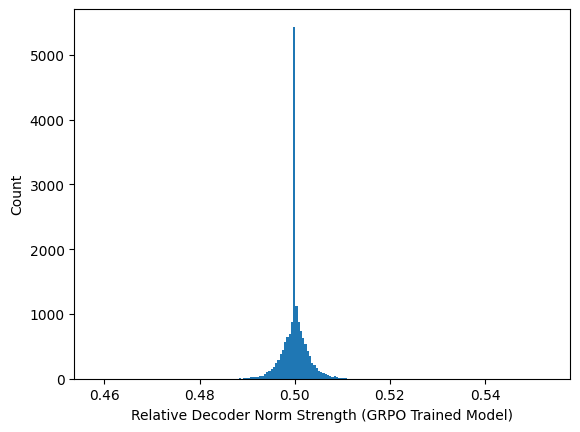

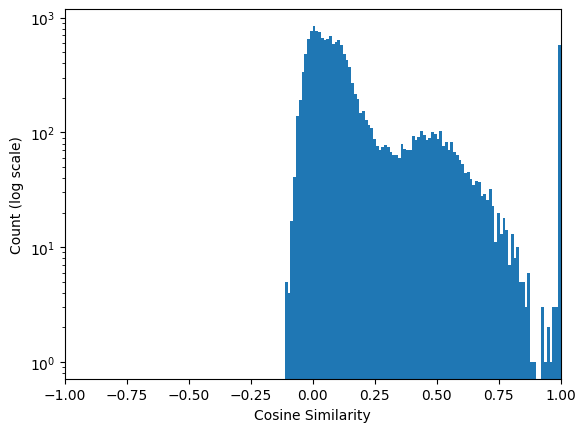

In [21]:
# Cell: Analyze Trained CrossCoder (Run AFTER training finishes)

import torch
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import os


# --- 0. Setup Output Directory ---
output_dir = Path("./analysis_results")
output_dir.mkdir(parents=True, exist_ok=True)

# --- 1. Load your locally trained CrossCoder ---
base_checkpoint_dir = Path("./checkpoints/")

version_dirs = sorted([d for d in base_checkpoint_dir.iterdir() if d.is_dir() and d.name.startswith("version_")])
if not version_dirs:
    raise FileNotFoundError(f"No version directories found in {base_checkpoint_dir}")
else:
    latest_version_dir = version_dirs[-1]
    print(f"Using latest checkpoint directory: {latest_version_dir}")

    checkpoint_files = list(latest_version_dir.glob("crosscoder_*.pt"))
    if not checkpoint_files:
        raise FileNotFoundError(f"No checkpoint files (.pt) found in {latest_version_dir}")
    else:
        versions = []
        for f in checkpoint_files:
            try:
                versions.append(int(f.stem.split('_')[1]))
            except (IndexError, ValueError):
                continue

        if not versions:
            raise ValueError(f"Could not parse checkpoint version numbers in {latest_version_dir}")

        latest_checkpoint_version = max(versions)
        print(f"Loading latest checkpoint: version {latest_checkpoint_version}")

        try:
            torch.set_grad_enabled(False)

            cross_coder = CrossCoder.load(str(latest_version_dir), latest_checkpoint_version)
            cross_coder.eval()
            print("Trained CrossCoder loaded successfully.")

            # --- 2. Perform Analysis ---
            W_dec = cross_coder.W_dec.data.float()

            norms = W_dec.norm(dim=-1, p=2)
            norms_A = norms[:, 0]
            norms_B = norms[:, 1]

            total_norm = norms.sum(dim=-1)
            relative_norms_B = norms_B / (total_norm + 1e-8)

            shared_latent_mask = (relative_norms_B > 0.3) & (relative_norms_B < 0.7)
            num_shared = shared_latent_mask.sum().item()
            print(f"Found {num_shared} shared features.")

            W_dec_A_shared = W_dec[shared_latent_mask, 0, :]
            W_dec_B_shared = W_dec[shared_latent_mask, 1, :]

            dot_products = (W_dec_A_shared * W_dec_B_shared).sum(dim=-1)
            norms_product = W_dec_A_shared.norm(dim=-1, p=2) * W_dec_B_shared.norm(dim=-1, p=2)
            cosine_sims = dot_products / (norms_product + 1e-8)

            # --- 3. Plotting & Saving ---
            print("Generating and saving plots...")

            # -------- Plot 1: Relative Decoder Norms --------
            plt.figure()
            plt.hist(relative_norms_B.cpu().numpy(), bins=200)
            # plt.title(f"Relative Decoder Norm - Layer {cross_coder.cfg.get('hook_point', 'N/A')}")
            plt.xlabel("Relative Decoder Norm Strength (GRPO Trained Model)")
            plt.ylabel("Count")

            plt.savefig(output_dir / "relative_norms.png", dpi=300, bbox_inches="tight")
            plt.show()

            # -------- Plot 2: Cosine Similarities --------
            if num_shared > 0:
                plt.figure()
                plt.hist(cosine_sims.cpu().numpy(), bins=100)
                plt.yscale("log")
                plt.xlim(-1, 1)

                # plt.title(f"Cosine Similarity (Shared Features) - Layer {cross_coder.cfg.get('hook_point', 'N/A')}")
                plt.xlabel("Cosine Similarity")
                plt.ylabel("Count (log scale)")

                plt.savefig(output_dir / "cosine_similarities.png", dpi=300, bbox_inches="tight")
                plt.show()
            else:
                print("Skipping cosine similarity plot: no shared features found.")

        except Exception as e:
            print(f"An error occurred: {e}")
            import traceback
            traceback.print_exc()
        finally:
            torch.set_grad_enabled(True)
            


In [22]:
import shutil

shutil.make_archive(
    '/kaggle/working/ORPO',  # output name (no .zip)
    'zip',
    '/kaggle/working/checkpoints'          # folder to zip
)


'/kaggle/working/ORPO.zip'

In [ ]:
import os

In [23]:
# Cell: Analyze Trained CrossCoder (Run AFTER training finishes)

import torch
import plotly.express as px
from pathlib import Path
import numpy as np
import os

# --- 0. Setup Output Directory ---
output_dir = Path("./analysis_results")
output_dir.mkdir(parents=True, exist_ok=True)

# --- 1. Load your locally trained CrossCoder ---
base_checkpoint_dir = Path("./checkpoints/")

version_dirs = sorted([d for d in base_checkpoint_dir.iterdir() if d.is_dir() and d.name.startswith("version_")])
if not version_dirs:
    raise FileNotFoundError(f"No version directories found in {base_checkpoint_dir}")
else:
    latest_version_dir = version_dirs[-1]
    print(f"Using latest checkpoint directory: {latest_version_dir}")

    checkpoint_files = list(latest_version_dir.glob("crosscoder_*.pt"))
    if not checkpoint_files:
        raise FileNotFoundError(f"No checkpoint files (.pt) found in {latest_version_dir}")
    else:
        versions = []
        for f in checkpoint_files:
             try:
                 versions.append(int(f.stem.split('_')[1]))
             except (IndexError, ValueError):
                 continue 
        if not versions:
             raise ValueError(f"Could not parse checkpoint version numbers in {latest_version_dir}")

        latest_checkpoint_version = max(versions)
        print(f"Loading latest checkpoint: version {latest_checkpoint_version}")

        try:
            torch.set_grad_enabled(False)
            cross_coder = CrossCoder.load(str(latest_version_dir), latest_checkpoint_version)
            cross_coder.eval()
            print("Trained CrossCoder loaded successfully.")

            # --- 2. Perform Analysis ---
            W_dec = cross_coder.W_dec.data.float() 

            norms = W_dec.norm(dim=-1, p=2) 
            norms_A = norms[:, 0]
            norms_B = norms[:, 1]

            total_norm = norms.sum(dim=-1)
            relative_norms_B = norms_B / (total_norm + 1e-8)

            shared_latent_mask = (relative_norms_B > 0.3) & (relative_norms_B < 0.7)
            num_shared = shared_latent_mask.sum().item()
            print(f"Found {num_shared} shared features.")

            W_dec_A_shared = W_dec[shared_latent_mask, 0, :]
            W_dec_B_shared = W_dec[shared_latent_mask, 1, :]

            dot_products = (W_dec_A_shared * W_dec_B_shared).sum(dim=-1)
            norms_product = W_dec_A_shared.norm(dim=-1, p=2) * W_dec_B_shared.norm(dim=-1, p=2)
            cosine_sims = dot_products / (norms_product + 1e-8)

            # --- 3. Plotting & Saving ---
            print("Generating and saving plots...")

            # Plot 1: Relative Decoder Norms
            fig_rel_norms = px.histogram(
                relative_norms_B.cpu().numpy(),
                title=f"Relative Decoder Norm - Layer {cross_coder.cfg.get('hook_point', 'N/A')}",
                labels={"value": "Relative Decoder Norm Strength (Model B)"},
                nbins=200,
            )
            fig_rel_norms.update_layout(showlegend=False)
            fig_rel_norms.update_xaxes(tickvals=[0, 0.25, 0.5, 0.75, 1.0], 
                                     ticktext=['0 (A)', '0.25', '0.5 (Shared)', '0.75', '1.0 (B)'])
            
            # Save Plot 1
            fig_rel_norms.write_image(str(output_dir / "relative_norms.png"))
            fig_rel_norms.write_html(str(output_dir / "relative_norms.html"))
            fig_rel_norms.show()

            # Plot 2: Cosine Similarities
            if num_shared > 0:
                fig_cos_sim = px.histogram(
                    cosine_sims.cpu().numpy(),
                    title=f"Cosine Similarity (Shared Features) - Layer {cross_coder.cfg.get('hook_point', 'N/A')}",
                    log_y=True,
                    range_x=[-1, 1],
                    nbins=100,
                    labels={"value": "Cosine Similarity"}
                )
                fig_cos_sim.update_layout(showlegend=False)
                
                # Save Plot 2
                fig_cos_sim.write_image(str(output_dir / "cosine_similarities.png"))
                fig_cos_sim.write_html(str(output_dir / "cosine_similarities.html"))
                fig_cos_sim.show()
            else:
                print("Skipping cosine similarity plot: no shared features found.")

        except Exception as e:
            print(f"An error occurred: {e}")
            import traceback
            traceback.print_exc()
        finally:
            torch.set_grad_enabled(True)

Using latest checkpoint directory: checkpoints/version_4
Loading latest checkpoint: version 0
Loading config from: checkpoints/version_4/crosscoder_0_cfg.json
Loaded Config:
{'batch_size': 2048,
 'beta1': 0.9,
 'beta2': 0.999,
 'buffer_mult': 64,
 'checkpoint_path': './checkpoints/',
 'd_in': 1024,
 'data_cache_dir': './cache/',
 'data_dir': './data/',
 'dec_init_norm': 0.08,
 'device': 'cuda:0',
 'dict_size': 16384,
 'enc_dtype': 'fp32',
 'hook_point': 'blocks.14.hook_resid_pre',
 'k_sparsity': 100,
 'l1_coeff': 0.0,
 'l1_warmup_fraction': 0.0,
 'log_every': 100,
 'lr': 5e-05,
 'lr_decay_start_fraction': 0.8,
 'lr_warmup_steps': 0,
 'model_batch_size': 1,
 'norm_batch_size': 16,
 'num_tokens': 10000000,
 'save_every': 5000,
 'seed': 49,
 'seq_len': 1024,
 'sparsity_type': 'batch_top_k',
 'wandb_entity': 'jithesh',
 'wandb_project': 'CrossCoder_Model_Diffing',
 'wandb_run_name': None}
CrossCoder (BatchTopK variant) initialized on device: cuda:0
Using BatchTopK sparsity with k=100
Loadi

choreographer.browsers.chromium.ChromeNotFoundError

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/plotly/io/_kaleido.py", line 398, in to_image
    img_bytes = kaleido.calc_fig_sync(
                ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaleido/__init__.py", line 171, in calc_fig_sync
    return _sync_server.oneshot_async_run(calc_fig, args=args, kwargs=kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaleido/_sync_server.py", line 131, in oneshot_async_run
    raise res
  File "/usr/local/lib/python3.12/dist-packages/kaleido/_sync_server.py", line 122, in run
    q.put(asyncio.run(func(*args, **kwargs)))
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/asyncio/runners.py", line 195, in run
    return runner.run(main)
           ^^^^^^^^^^^

In [24]:
import os
os.listdir()

['.virtual_documents',
 'cache',
 'checkpoints',
 'ORPO.zip',
 'wandb',
 'analysis_results',
 'state.db',
 'data']

In [25]:
# Cell: Analyze Trained CrossCoder (Run AFTER training finishes)


import torch
import plotly.express as px
from pathlib import Path
import numpy as np


# Ensure the CrossCoder class definition cell has been run


# --- 1. Load your locally trained CrossCoder ---
# Set the path to your checkpoint directory (should match cfg['checkpoint_path'])
base_checkpoint_dir = Path("./checkpoints/")


# Find the latest version directory (e.g., version_0, version_1, etc.)
version_dirs = sorted([d for d in base_checkpoint_dir.iterdir() if d.is_dir() and d.name.startswith("version_")])
if not version_dirs:
    print(f"Error: No version directories found in {base_checkpoint_dir}")
    # Handle error appropriately, maybe raise exception or exit
    raise FileNotFoundError(f"No version directories found in {base_checkpoint_dir}")
else:
    latest_version_dir = version_dirs[-1] # Get the latest version directory path
    print(f"Using latest checkpoint directory: {latest_version_dir}")


    # Find the latest checkpoint number within that directory
    checkpoint_files = list(latest_version_dir.glob("crosscoder_*.pt"))
    if not checkpoint_files:
        print(f"Error: No checkpoint files (.pt) found in {latest_version_dir}")
        raise FileNotFoundError(f"No checkpoint files (.pt) found in {latest_version_dir}")
    else:
        # Extract version numbers from filenames and find the latest
        versions = []
        for f in checkpoint_files:
             try:
                 versions.append(int(f.stem.split('_')[1]))
             except (IndexError, ValueError):
                 continue # Ignore files not matching the pattern
        if not versions:
             print(f"Error: Could not parse checkpoint version numbers in {latest_version_dir}")
             raise ValueError(f"Could not parse checkpoint version numbers in {latest_version_dir}")


        latest_checkpoint_version = max(versions)
        print(f"Loading latest checkpoint: version {latest_checkpoint_version}")


        # Load the CrossCoder using the .load() method
        try:
            # Disable gradient calculations for analysis
            torch.set_grad_enabled(False)
            cross_coder = CrossCoder.load(str(latest_version_dir), latest_checkpoint_version)
            cross_coder.eval() # Set model to evaluation mode
            print("Trained CrossCoder loaded successfully.")


            # --- 2. Perform Analysis (Calculations) ---
            print("Analyzing decoder weights...")
            W_dec = cross_coder.W_dec.data.float() # Use float32 for analysis stability


            # Calculate norms for each model's decoder vectors per feature
            norms = W_dec.norm(dim=-1, p=2) # Shape: [d_hidden, 2]
            norms_A = norms[:, 0]
            norms_B = norms[:, 1]


            # Calculate relative norm contribution of Model B
            total_norm = norms.sum(dim=-1)
            relative_norms_B = norms_B / (total_norm + 1e-8) # Shape: [d_hidden]


            # Identify shared features based on relative norms
            shared_latent_mask = (relative_norms_B > 0.3) & (relative_norms_B < 0.7) # Shape: [d_hidden]
            num_shared = shared_latent_mask.sum().item()
            print(f"Found {num_shared} shared features (relative norm between 0.3 and 0.7).")


            # Calculate cosine similarity for shared features
            W_dec_A_shared = W_dec[shared_latent_mask, 0, :]
            W_dec_B_shared = W_dec[shared_latent_mask, 1, :]


            dot_products = (W_dec_A_shared * W_dec_B_shared).sum(dim=-1)
            norms_product = W_dec_A_shared.norm(dim=-1, p=2) * W_dec_B_shared.norm(dim=-1, p=2)
            cosine_sims = dot_products / (norms_product + 1e-8) # Shape: [num_shared]


            # --- 3. Plotting Results ---
            print("Generating plots...")


            # Plot 1: Histogram of Relative Decoder Norms
            fig_rel_norms = px.histogram(
                relative_norms_B.cpu().numpy(),
                title=f"Relative Decoder Norm ({cross_coder.cfg.get('model_name_B', 'Model B')} / Total) - Layer {cross_coder.cfg.get('hook_point', 'N/A')}",
                labels={"value": "Relative Decoder Norm Strength (Model B)"},
                nbins=200,
            )
            fig_rel_norms.update_layout(showlegend=False)
            fig_rel_norms.update_yaxes(title_text="Number of Latent Features")
            fig_rel_norms.update_xaxes(
                tickvals=[0, 0.25, 0.5, 0.75, 1.0],
                ticktext=['0 (Model A)', '0.25', '0.5 (Shared)', '0.75', '1.0 (Model B)']
            )
            fig_rel_norms.show()


            # Plot 2: Histogram of Cosine Similarities for Shared Features
            if num_shared > 0:
                fig_cos_sim = px.histogram(
                    cosine_sims.cpu().numpy(),
                    title=f"Cosine Similarity of Decoder Vectors for Shared Features - Layer {cross_coder.cfg.get('hook_point', 'N/A')}",
                    log_y=True,  # Sets the y-axis to log scale
                    range_x=[-1, 1],  # Sets the x-axis range from -1 to 1
                    nbins=100,
                    labels={"value": "Cosine Similarity"}
                )
                fig_cos_sim.update_layout(showlegend=False)
                fig_cos_sim.update_yaxes(title_text="Number of Shared Latents (log scale)")
                fig_cos_sim.show()
            else:
                print("Skipping cosine similarity plot as no shared features were found based on the criteria.")


        except FileNotFoundError as e:
            print(e)
        except Exception as e:
            print(f"An error occurred during loading or analysis: {e}")
            import traceback
            traceback.print_exc()
        finally:
            # Re-enable gradients if needed for subsequent cells
            torch.set_grad_enabled(True)

Using latest checkpoint directory: checkpoints/version_4
Loading latest checkpoint: version 0
Loading config from: checkpoints/version_4/crosscoder_0_cfg.json
Loaded Config:
{'batch_size': 2048,
 'beta1': 0.9,
 'beta2': 0.999,
 'buffer_mult': 64,
 'checkpoint_path': './checkpoints/',
 'd_in': 1024,
 'data_cache_dir': './cache/',
 'data_dir': './data/',
 'dec_init_norm': 0.08,
 'device': 'cuda:0',
 'dict_size': 16384,
 'enc_dtype': 'fp32',
 'hook_point': 'blocks.14.hook_resid_pre',
 'k_sparsity': 100,
 'l1_coeff': 0.0,
 'l1_warmup_fraction': 0.0,
 'log_every': 100,
 'lr': 5e-05,
 'lr_decay_start_fraction': 0.8,
 'lr_warmup_steps': 0,
 'model_batch_size': 1,
 'norm_batch_size': 16,
 'num_tokens': 10000000,
 'save_every': 5000,
 'seed': 49,
 'seq_len': 1024,
 'sparsity_type': 'batch_top_k',
 'wandb_entity': 'jithesh',
 'wandb_project': 'CrossCoder_Model_Diffing',
 'wandb_run_name': None}
CrossCoder (BatchTopK variant) initialized on device: cuda:0
Using BatchTopK sparsity with k=100
Loadi